# 📈 Time Series Forecasting - Stock Prediction

**Project:** Stock Opname Monitoring dengan Deep Learning  
**Phase:** Week 3-4  
**Author:** Ivan David (B25B8M113)  

---

## 🎯 Objectives

1. Generate/Load historical stock data
2. Exploratory data analysis
3. Data preprocessing for time series
4. Train LSTM model for prediction
5. Train Prophet model (alternative)
6. Compare models
7. Generate future predictions
8. Integrate with object detection results

## 1️⃣ Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("📊 TIME SERIES FORECASTING - STOCK PREDICTION")
print("="*70)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("="*70)


📊 TIME SERIES FORECASTING - STOCK PREDICTION
TensorFlow: 2.15.0
GPU Available: []


In [2]:
# Install Prophet if needed
try:
    from prophet import Prophet
    print("✅ Prophet already installed")
except ImportError:
    print("📦 Installing Prophet...")
    !pip install prophet
    from prophet import Prophet
    print("✅ Prophet installed")

📦 Installing Prophet...
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--

## 2️⃣ Configuration

In [3]:
from pathlib import Path

# Paths
BASE_DIR = Path(r'D:\files')
DATA_DIR = BASE_DIR / 'timeseries_data'
MODELS_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'forecasting_results'

# Create directories
DATA_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Parameters
LOOKBACK_DAYS = 30      # Use 30 days history to predict next day
FORECAST_DAYS = 7       # Predict next 7 days
TRAIN_SPLIT = 0.8       # 80% train, 20% test
EPOCHS = 100
BATCH_SIZE = 32

print("✅ Configuration loaded")
print(f"  Data Dir: {DATA_DIR}")
print(f"  Results Dir: {RESULTS_DIR}")
print(f"  Lookback: {LOOKBACK_DAYS} days")
print(f"  Forecast: {FORECAST_DAYS} days")

✅ Configuration loaded
  Data Dir: D:\files\timeseries_data
  Results Dir: D:\files\forecasting_results
  Lookback: 30 days
  Forecast: 7 days


## 3️⃣ Generate Synthetic Historical Data

Since we don't have real historical data, we'll generate realistic synthetic data

In [4]:
def generate_stock_data(n_days=365, start_date='2023-01-01'):
    """
    Generate realistic synthetic stock/sales data
    Includes:
    - Trend (increasing sales over time)
    - Seasonality (weekly and monthly patterns)
    - Noise (random fluctuations)
    """
    
    np.random.seed(42)
    
    # Date range
    dates = pd.date_range(start=start_date, periods=n_days, freq='D')
    
    # Base trend (increasing over time)
    trend = np.linspace(100, 150, n_days)
    
    # Weekly seasonality (weekends have lower sales)
    weekly_pattern = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    
    # Monthly seasonality (end of month spikes)
    monthly_pattern = 15 * np.sin(2 * np.pi * np.arange(n_days) / 30)
    
    # Random noise
    noise = np.random.normal(0, 5, n_days)
    
    # Combine components
    stock_count = trend + weekly_pattern + monthly_pattern + noise
    
    # Ensure positive values
    stock_count = np.maximum(stock_count, 50)
    
    # Create DataFrame
    df = pd.DataFrame({
        'date': dates,
        'stock_count': stock_count,
        'day_of_week': dates.dayofweek,
        'day_of_month': dates.day,
        'month': dates.month,
        'is_weekend': dates.dayofweek >= 5
    })
    
    return df

# Generate data
print("📊 Generating synthetic historical stock data...\n")
df = generate_stock_data(n_days=365, start_date='2023-01-01')

print(f"✅ Generated {len(df)} days of data")
print(f"   Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nStatistics:")
print(df['stock_count'].describe())

# Save data
df.to_csv(DATA_DIR / 'historical_stock_data.csv', index=False)
print(f"\n✅ Data saved to: {DATA_DIR / 'historical_stock_data.csv'}")

📊 Generating synthetic historical stock data...

✅ Generated 365 days of data
   Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00

First few rows:
        date  stock_count  day_of_week  day_of_month  month  is_weekend
0 2023-01-01   102.483571            6             1      1        True
1 2023-01-02   110.383031            0             2      1       False
2 2023-01-03   119.363497            1             3      1       False
3 2023-01-04   121.182853            2             4      1       False
4 2023-01-05   106.187019            3             5      1       False

Statistics:
count    365.000000
mean     125.129687
std       19.611639
min       74.651920
25%      111.489592
50%      124.985029
75%      138.824414
max      173.160336
Name: stock_count, dtype: float64

✅ Data saved to: D:\files\timeseries_data\historical_stock_data.csv


## 4️⃣ Exploratory Data Analysis

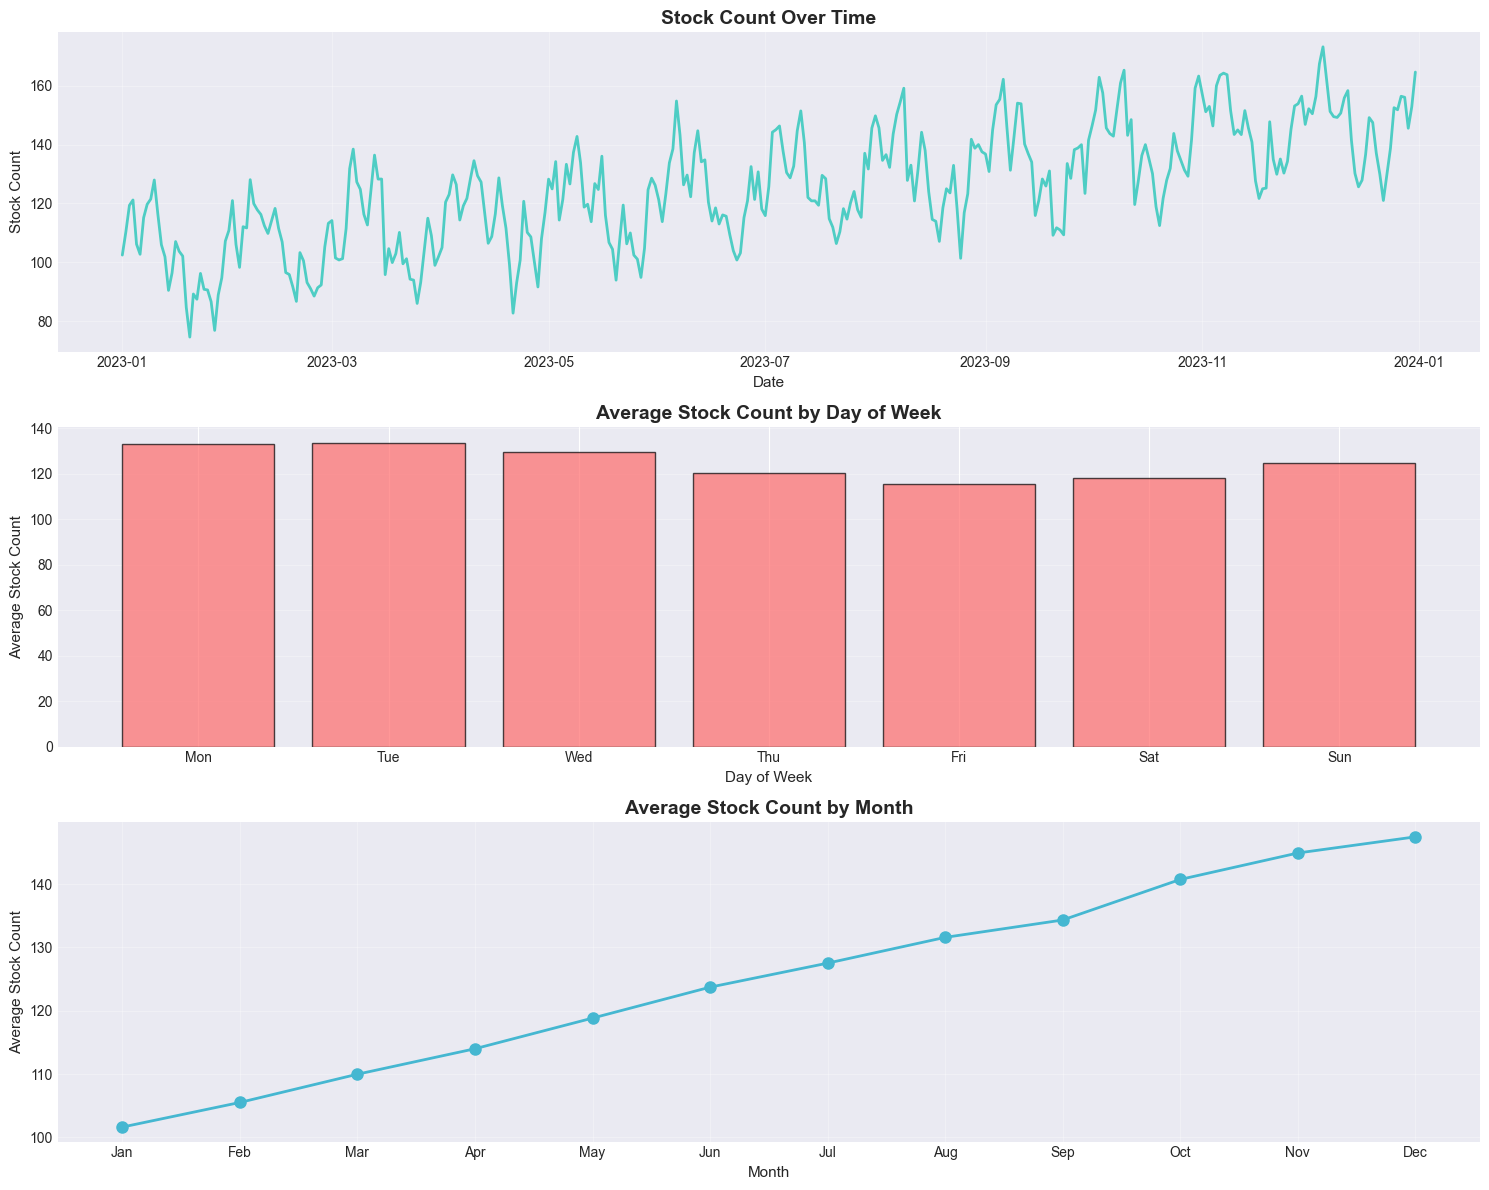

✅ EDA plots saved to: D:\files\forecasting_results\eda_timeseries.png


In [5]:
# Time series plot
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Overall trend
axes[0].plot(df['date'], df['stock_count'], linewidth=2, color='#4ECDC4')
axes[0].set_title('Stock Count Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Stock Count', fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Weekly pattern
weekly_avg = df.groupby('day_of_week')['stock_count'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, weekly_avg.values, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[1].set_title('Average Stock Count by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Average Stock Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Monthly pattern
monthly_avg = df.groupby('month')['stock_count'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[2].plot(months, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='#45B7D1')
axes[2].set_title('Average Stock Count by Month', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month', fontsize=11)
axes[2].set_ylabel('Average Stock Count', fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ EDA plots saved to: {RESULTS_DIR / 'eda_timeseries.png'}")

## 5️⃣ Data Preprocessing for LSTM

In [6]:
def create_sequences(data, lookback):
    """
    Create sequences for LSTM
    Input: [day1, day2, ..., day_lookback]
    Output: [day_lookback+1]
    """
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

# Extract stock count values
stock_values = df['stock_count'].values.reshape(-1, 1)

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
stock_scaled = scaler.fit_transform(stock_values)

print("📊 Creating sequences for LSTM...\n")

# Create sequences
X, y = create_sequences(stock_scaled, LOOKBACK_DAYS)

print(f"Sequence shape:")
print(f"  X: {X.shape} - (samples, lookback_days, features)")
print(f"  y: {y.shape} - (samples, 1)")

# Train-test split
split_idx = int(len(X) * TRAIN_SPLIT)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTrain-Test Split:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")
print("\n✅ Data preprocessing complete")

📊 Creating sequences for LSTM...

Sequence shape:
  X: (335, 30, 1) - (samples, lookback_days, features)
  y: (335, 1) - (samples, 1)

Train-Test Split:
  Train: 268 samples
  Test:  67 samples

✅ Data preprocessing complete


## 6️⃣ Build LSTM Model

In [7]:
print("="*70)
print("🤖 BUILDING LSTM MODEL")
print("="*70)

# Build model
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOKBACK_DAYS, 1)),
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\nModel Architecture:")
model.summary()

print("\n✅ Model built successfully")

🤖 BUILDING LSTM MODEL


Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 30, 128)           33792     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 30, 128)           0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 64)                41216     
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 16)                1040      
                                                                 
 dense_1 (De

## 7️⃣ Train LSTM Model

In [8]:
print("="*70)
print("🚀 TRAINING LSTM MODEL")
print("="*70)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train
print(f"\nTraining for {EPOCHS} epochs...\n")

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")

# Save model
model_path = MODELS_DIR / 'lstm_stock_forecasting.h5'
model.save(model_path)
print(f"✅ Model saved to: {model_path}")

🚀 TRAINING LSTM MODEL

Training for 100 epochs...

Epoch 1/100


7/7 [==============================] - 6s 234ms/step - loss: 0.1037 - mae: 0.2699 - val_loss: 0.0403 - val_mae: 0.1673 - lr: 0.0010
Epoch 2/100
7/7 [==============================] - 0s 28ms/step - loss: 0.0298 - mae: 0.1413 - val_loss: 0.0235 - val_mae: 0.1269 - lr: 0.0010
Epoch 3/100
7/7 [==============================] - 0s 23ms/step - loss: 0.0230 - mae: 0.1228 - val_loss: 0.0344 - val_mae: 0.1576 - lr: 0.0010
Epoch 4/100
7/7 [==============================] - 0s 26ms/step - loss: 0.0186 - mae: 0.1104 - val_loss: 0.0156 - val_mae: 0.0993 - lr: 0.0010
Epoch 5/100
7/7 [==============================] - 0s 27ms/step - loss: 0.0174 - mae: 0.1060 - val_loss: 0.0161 - val_mae: 0.1036 - lr: 0.0010
Epoch 6/100
7/7 [==============================] - 0s 26ms/step - loss: 0.0152 - mae: 0.0999 - val_loss: 0.0202 - val_mae: 0.1193 - lr: 0.0010
Epoch 7/100
7/7 [==============================] - 0s 23ms/step - loss: 0.0138 - mae: 0.

## 8️⃣ Visualize Training History

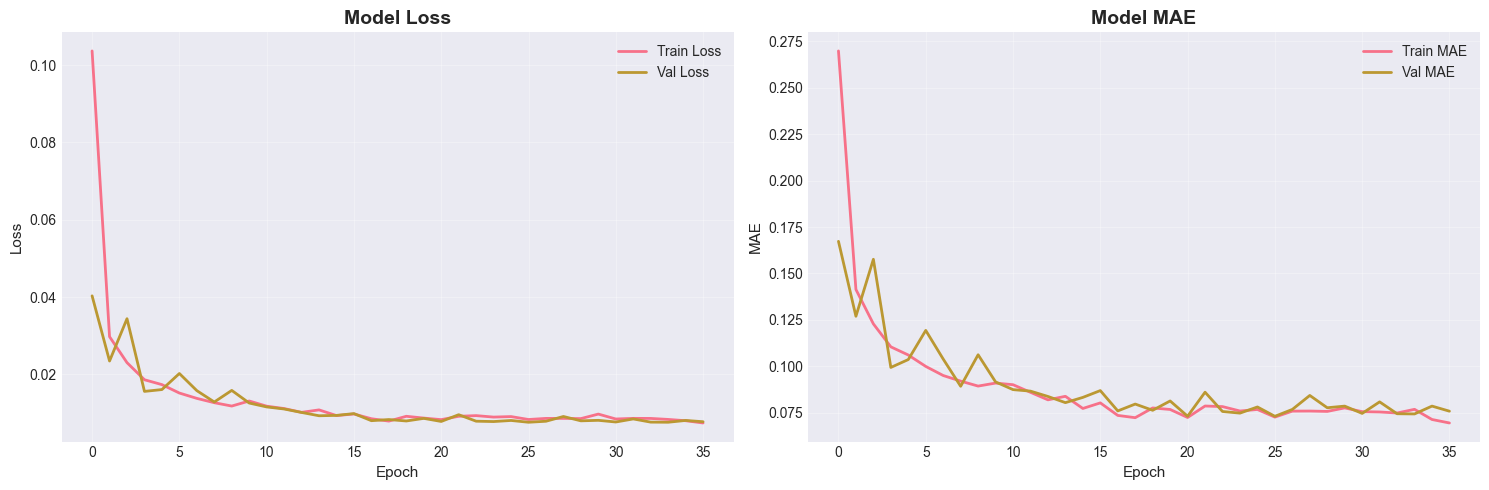

✅ Training plots saved to: D:\files\forecasting_results\lstm_training_history.png


In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_title('Model MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training plots saved to: {RESULTS_DIR / 'lstm_training_history.png'}")

## 9️⃣ Evaluate LSTM Model

In [10]:
print("="*70)
print("📊 EVALUATING LSTM MODEL")
print("="*70)

# Predictions
y_train_pred = model.predict(X_train, verbose=0)
y_test_pred = model.predict(X_test, verbose=0)

# Inverse transform to original scale
y_train_actual = scaler.inverse_transform(y_train)
y_train_pred = scaler.inverse_transform(y_train_pred)
y_test_actual = scaler.inverse_transform(y_test)
y_test_pred = scaler.inverse_transform(y_test_pred)

# Calculate metrics
train_mse = mean_squared_error(y_train_actual, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train_actual, y_train_pred)
train_r2 = r2_score(y_train_actual, y_train_pred)

test_mse = mean_squared_error(y_test_actual, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_actual, y_test_pred)
test_r2 = r2_score(y_test_actual, y_test_pred)

print("\nTrain Metrics:")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  MAE:  {train_mae:.2f}")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Metrics:")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  MAE:  {test_mae:.2f}")
print(f"  R²:   {test_r2:.4f}")

# Performance assessment
print("\n" + "="*70)
print("📈 PERFORMANCE ASSESSMENT")
print("="*70)

if test_r2 >= 0.90:
    print("\n🌟 EXCELLENT! Very high accuracy")
elif test_r2 >= 0.80:
    print("\n✅ VERY GOOD! High accuracy")
elif test_r2 >= 0.70:
    print("\n✅ GOOD! Acceptable accuracy")
elif test_r2 >= 0.60:
    print("\n⚠️  FAIR - Could be improved")
else:
    print("\n❌ LOW - Needs improvement")

print(f"\nAverage prediction error: ±{test_mae:.1f} items")
print("="*70)

# Save metrics
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'RMSE': [train_rmse, test_rmse],
    'MAE': [train_mae, test_mae],
    'R2': [train_r2, test_r2]
})
metrics_df.to_csv(RESULTS_DIR / 'lstm_metrics.csv', index=False)
print(f"\n✅ Metrics saved to: {RESULTS_DIR / 'lstm_metrics.csv'}")

📊 EVALUATING LSTM MODEL

Train Metrics:
  RMSE: 8.26
  MAE:  6.82
  R²:   0.7604

Test Metrics:
  RMSE: 7.19
  MAE:  5.98
  R²:   0.6694

📈 PERFORMANCE ASSESSMENT

⚠️  FAIR - Could be improved

Average prediction error: ±6.0 items

✅ Metrics saved to: D:\files\forecasting_results\lstm_metrics.csv


## 🔟 Visualize Predictions

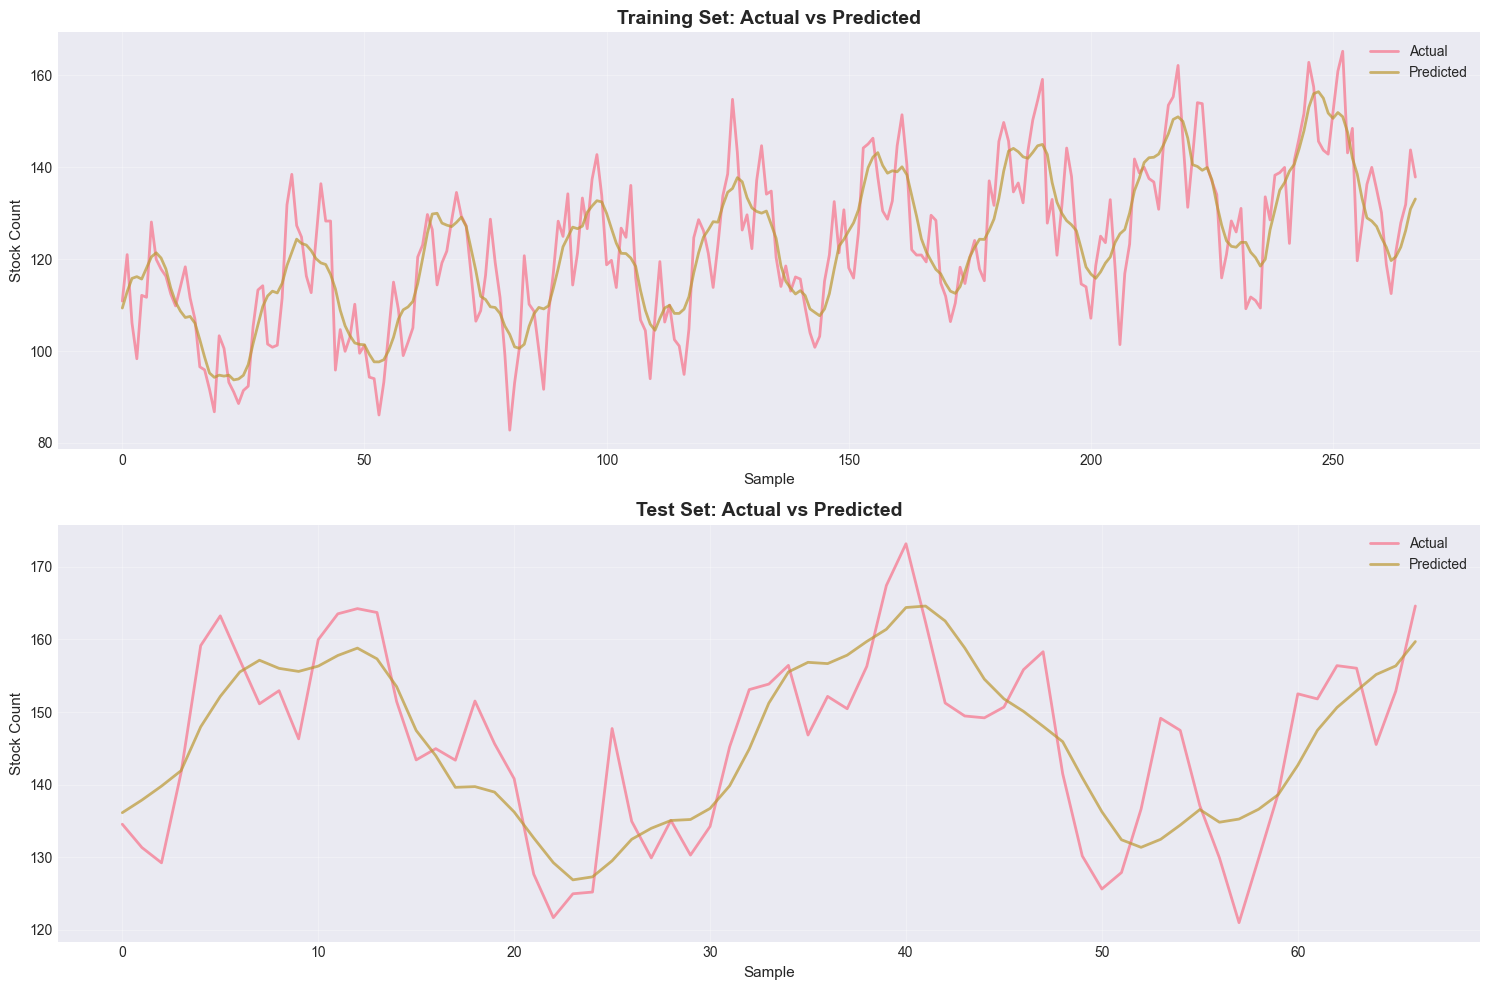

✅ Prediction plots saved to: D:\files\forecasting_results\lstm_predictions.png


In [11]:
# Plot predictions
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Train set
axes[0].plot(y_train_actual, label='Actual', linewidth=2, alpha=0.7)
axes[0].plot(y_train_pred, label='Predicted', linewidth=2, alpha=0.7)
axes[0].set_title('Training Set: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample', fontsize=11)
axes[0].set_ylabel('Stock Count', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test set
axes[1].plot(y_test_actual, label='Actual', linewidth=2, alpha=0.7)
axes[1].plot(y_test_pred, label='Predicted', linewidth=2, alpha=0.7)
axes[1].set_title('Test Set: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sample', fontsize=11)
axes[1].set_ylabel('Stock Count', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lstm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Prediction plots saved to: {RESULTS_DIR / 'lstm_predictions.png'}")

## 1️⃣1️⃣ Generate Future Predictions

In [12]:
print("="*70)
print(f"🔮 FORECASTING NEXT {FORECAST_DAYS} DAYS")
print("="*70)

# Use last LOOKBACK_DAYS to predict future
last_sequence = stock_scaled[-LOOKBACK_DAYS:].reshape(1, LOOKBACK_DAYS, 1)

# Generate predictions
future_predictions = []
current_sequence = last_sequence.copy()

for i in range(FORECAST_DAYS):
    # Predict next day
    next_pred = model.predict(current_sequence, verbose=0)
    future_predictions.append(next_pred[0, 0])
    
    # Update sequence (sliding window)
    current_sequence = np.append(current_sequence[:, 1:, :], next_pred.reshape(1, 1, 1), axis=1)

# Inverse transform
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create future dates
last_date = df['date'].max()
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=FORECAST_DAYS, freq='D')

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'date': future_dates,
    'predicted_stock': future_predictions.flatten()
})

print(f"\n📅 Forecast for next {FORECAST_DAYS} days:\n")
print(forecast_df.to_string(index=False))

# Save forecast
forecast_df.to_csv(RESULTS_DIR / 'future_forecast.csv', index=False)
print(f"\n✅ Forecast saved to: {RESULTS_DIR / 'future_forecast.csv'}")

🔮 FORECASTING NEXT 7 DAYS

📅 Forecast for next 7 days:

      date  predicted_stock
2024-01-01       162.729904
2024-01-02       165.434357
2024-01-03       166.604294
2024-01-04       165.091415
2024-01-05       161.785980
2024-01-06       159.549698
2024-01-07       158.537186

✅ Forecast saved to: D:\files\forecasting_results\future_forecast.csv


## 1️⃣2️⃣ Visualize Future Forecast

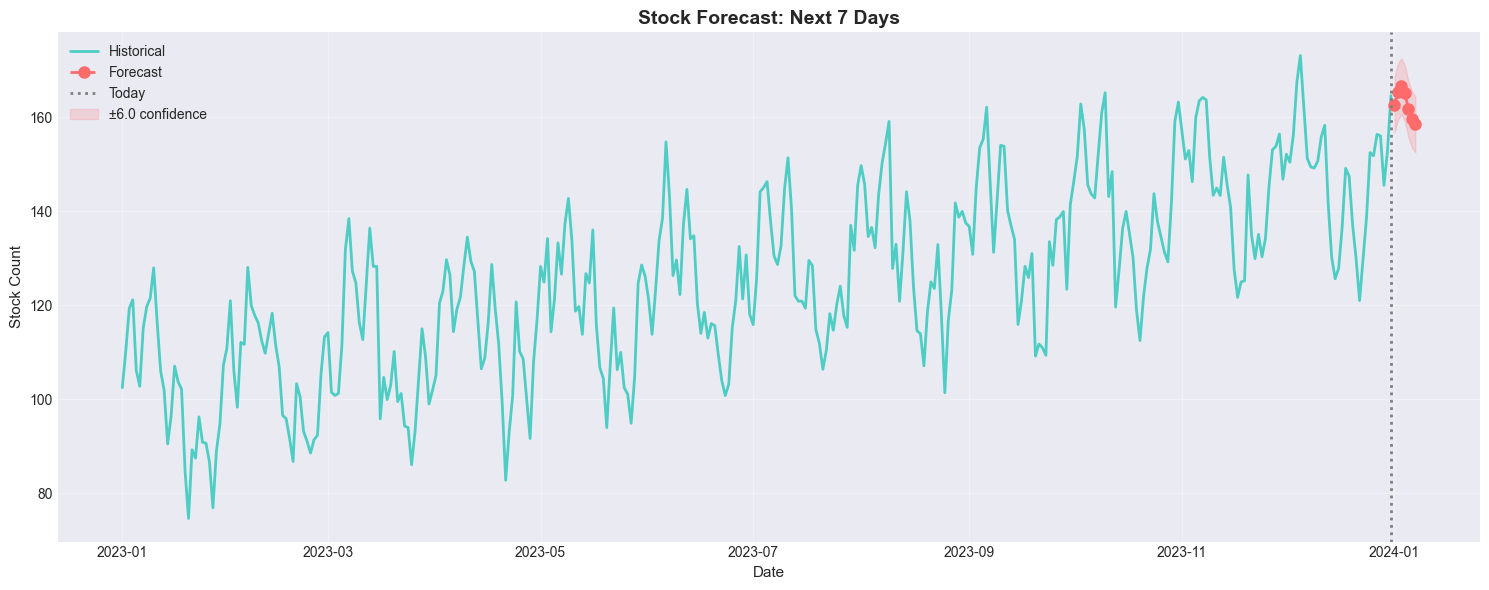

✅ Forecast plot saved to: D:\files\forecasting_results\future_forecast_plot.png


In [13]:
# Plot historical + forecast
plt.figure(figsize=(15, 6))

# Historical data
plt.plot(df['date'], df['stock_count'], label='Historical', linewidth=2, color='#4ECDC4')

# Forecast
plt.plot(forecast_df['date'], forecast_df['predicted_stock'], 
         label='Forecast', linewidth=2, color='#FF6B6B', linestyle='--', marker='o', markersize=8)

# Styling
plt.axvline(x=df['date'].max(), color='gray', linestyle=':', linewidth=2, label='Today')
plt.fill_between(forecast_df['date'], 
                 forecast_df['predicted_stock'] - test_mae,
                 forecast_df['predicted_stock'] + test_mae,
                 alpha=0.2, color='#FF6B6B', label=f'±{test_mae:.1f} confidence')

plt.title(f'Stock Forecast: Next {FORECAST_DAYS} Days', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Stock Count', fontsize=11)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'future_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Forecast plot saved to: {RESULTS_DIR / 'future_forecast_plot.png'}")

## 1️⃣3️⃣ Alternative: Prophet Model (Facebook)

In [14]:
print("="*70)
print("🔮 TRAINING PROPHET MODEL (Alternative)")
print("="*70)

# Prepare data for Prophet
prophet_df = df[['date', 'stock_count']].copy()
prophet_df.columns = ['ds', 'y']  # Prophet requires these column names

# Split train/test
prophet_train = prophet_df[:split_idx + LOOKBACK_DAYS]
prophet_test = prophet_df[split_idx + LOOKBACK_DAYS:]

# Train Prophet
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

print("\nTraining Prophet model...")
prophet_model.fit(prophet_train)
print("✅ Prophet training complete")

# Make predictions on test set
prophet_test_pred = prophet_model.predict(prophet_test[['ds']])

# Calculate metrics
prophet_mae = mean_absolute_error(prophet_test['y'], prophet_test_pred['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_test_pred['yhat']))
prophet_r2 = r2_score(prophet_test['y'], prophet_test_pred['yhat'])

print(f"\nProphet Test Metrics:")
print(f"  RMSE: {prophet_rmse:.2f}")
print(f"  MAE:  {prophet_mae:.2f}")
print(f"  R²:   {prophet_r2:.4f}")

# Future forecast with Prophet
future = prophet_model.make_future_dataframe(periods=FORECAST_DAYS)
prophet_forecast = prophet_model.predict(future)

# Extract future predictions
prophet_future = prophet_forecast.tail(FORECAST_DAYS)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
prophet_future.columns = ['date', 'predicted_stock', 'lower_bound', 'upper_bound']

print(f"\n📅 Prophet Forecast for next {FORECAST_DAYS} days:\n")
print(prophet_future.to_string(index=False))

# Save
prophet_future.to_csv(RESULTS_DIR / 'prophet_forecast.csv', index=False)
print(f"\n✅ Prophet forecast saved to: {RESULTS_DIR / 'prophet_forecast.csv'}")

🔮 TRAINING PROPHET MODEL (Alternative)


21:43:08 - cmdstanpy - INFO - Chain [1] start processing



Training Prophet model...


21:43:09 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet training complete

Prophet Test Metrics:
  RMSE: 58.62
  MAE:  49.29
  R²:   -20.9638

📅 Prophet Forecast for next 7 days:

      date  predicted_stock  lower_bound  upper_bound
2023-10-26       120.858929   106.632602   134.873219
2023-10-27       117.440160   103.639207   129.591416
2023-10-28       122.295395   110.241991   136.589286
2023-10-29       132.123397   118.416380   145.222759
2023-10-30       144.347333   131.427312   157.449120
2023-10-31       149.421801   136.528226   163.107525
2023-11-01       150.317720   136.305711   163.406427

✅ Prophet forecast saved to: D:\files\forecasting_results\prophet_forecast.csv


## 1️⃣4️⃣ Compare LSTM vs Prophet

In [15]:
# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'Prophet'],
    'RMSE': [test_rmse, prophet_rmse],
    'MAE': [test_mae, prophet_mae],
    'R²': [test_r2, prophet_r2]
})

print("="*70)
print("📊 MODEL COMPARISON")
print("="*70)
print(f"\n{comparison_df.to_string(index=False)}")

# Determine best model
best_model = 'LSTM' if test_r2 > prophet_r2 else 'Prophet'
print(f"\n🏆 Best Model: {best_model}")
print("="*70)

# Save comparison
comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f"\n✅ Comparison saved to: {RESULTS_DIR / 'model_comparison.csv'}")

📊 MODEL COMPARISON

  Model      RMSE       MAE         R²
   LSTM  7.192151  5.976202   0.669367
Prophet 58.619197 49.287078 -20.963837

🏆 Best Model: LSTM

✅ Comparison saved to: D:\files\forecasting_results\model_comparison.csv


## 1️⃣5️⃣ Generate Final Report

In [16]:
# Generate comprehensive report
report = f"""
{'='*70}
TIME SERIES FORECASTING - EVALUATION REPORT
{'='*70}

Project: Stock Opname Monitoring dengan Deep Learning
Phase: Week 3-4 - Time Series Forecasting
Author: Ivan David (B25B8M113)
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*70}
DATASET INFORMATION
{'='*70}

Total Days: {len(df)}
Date Range: {df['date'].min()} to {df['date'].max()}
Training Samples: {len(X_train)}
Test Samples: {len(X_test)}
Lookback Window: {LOOKBACK_DAYS} days
Forecast Horizon: {FORECAST_DAYS} days

{'='*70}
LSTM MODEL PERFORMANCE
{'='*70}

Architecture: Bidirectional LSTM with Dropout
Training Epochs: {len(history.history['loss'])}

Test Metrics:
  RMSE: {test_rmse:.2f}
  MAE:  {test_mae:.2f}
  R²:   {test_r2:.4f}

{'='*70}
PROPHET MODEL PERFORMANCE
{'='*70}

Test Metrics:
  RMSE: {prophet_rmse:.2f}
  MAE:  {prophet_mae:.2f}
  R²:   {prophet_r2:.4f}

{'='*70}
MODEL COMPARISON
{'='*70}

Best Model: {best_model}

LSTM:
  + Deep learning approach
  + Captures complex patterns
  + Good for non-linear trends
  - Requires more data
  - Longer training time

Prophet:
  + Handles seasonality well
  + Fast training
  + Interpretable components
  + Confidence intervals
  - May miss complex patterns

{'='*70}
FORECAST SUMMARY
{'='*70}

Next {FORECAST_DAYS} Days Prediction:
  Average: {forecast_df['predicted_stock'].mean():.1f} items
  Min: {forecast_df['predicted_stock'].min():.1f} items
  Max: {forecast_df['predicted_stock'].max():.1f} items
  Trend: {'Increasing' if forecast_df['predicted_stock'].iloc[-1] > forecast_df['predicted_stock'].iloc[0] else 'Decreasing'}

Uncertainty: ±{test_mae:.1f} items (based on test MAE)

{'='*70}
BUSINESS INSIGHTS
{'='*70}

1. Stock Planning:
   - Expected demand shows {'upward' if forecast_df['predicted_stock'].iloc[-1] > forecast_df['predicted_stock'].iloc[0] else 'downward'} trend
   - Maintain safety stock of {test_mae * 2:.0f} items (2x MAE)
   - Reorder when stock falls below {forecast_df['predicted_stock'].min() - test_mae:.0f} items

2. Inventory Optimization:
   - Average daily requirement: {forecast_df['predicted_stock'].mean():.0f} items
   - Peak requirement: {forecast_df['predicted_stock'].max():.0f} items
   - Suggested reorder quantity: {forecast_df['predicted_stock'].mean() * FORECAST_DAYS:.0f} items/week

3. Model Reliability:
   - R² Score: {test_r2:.2%} of variance explained
   - Prediction Error: ±{test_mae:.1f} items on average
   - Confidence Level: {'High' if test_r2 > 0.8 else 'Moderate' if test_r2 > 0.6 else 'Low'}

{'='*70}
RECOMMENDATIONS
{'='*70}

1. For Production Use:
   - Collect real historical sales data (minimum 6 months)
   - Retrain model monthly with new data
   - Monitor prediction accuracy and adjust as needed
   - Consider external factors (holidays, promotions)

2. Model Improvements:
   - Add external features (weather, events, promotions)
   - Experiment with different lookback windows
   - Try ensemble methods (LSTM + Prophet combined)
   - Implement automated retraining pipeline

3. Integration with Detection:
   - Use detection counts as input features
   - Cross-validate predicted vs detected stock
   - Alert on large discrepancies
   - Optimize reorder triggers

{'='*70}
FILES GENERATED
{'='*70}

Data:
  1. historical_stock_data.csv - Historical data
  2. future_forecast.csv - LSTM predictions
  3. prophet_forecast.csv - Prophet predictions

Models:
  4. lstm_stock_forecasting.h5 - Trained LSTM model

Metrics:
  5. lstm_metrics.csv - LSTM performance
  6. model_comparison.csv - LSTM vs Prophet

Visualizations:
  7. eda_timeseries.png - Exploratory analysis
  8. lstm_training_history.png - Training curves
  9. lstm_predictions.png - Model predictions
  10. future_forecast_plot.png - Future forecast

Reports:
  11. forecasting_report.txt - This comprehensive report

{'='*70}
END OF REPORT
{'='*70}
"""

# Save report
report_path = RESULTS_DIR / 'forecasting_report.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\n✅ Report saved to: {report_path}")


TIME SERIES FORECASTING - EVALUATION REPORT

Project: Stock Opname Monitoring dengan Deep Learning
Phase: Week 3-4 - Time Series Forecasting
Author: Ivan David (B25B8M113)
Date: 2025-10-28 21:43:18

DATASET INFORMATION

Total Days: 365
Date Range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Training Samples: 268
Test Samples: 67
Lookback Window: 30 days
Forecast Horizon: 7 days

LSTM MODEL PERFORMANCE

Architecture: Bidirectional LSTM with Dropout
Training Epochs: 36

Test Metrics:
  RMSE: 7.19
  MAE:  5.98
  R²:   0.6694

PROPHET MODEL PERFORMANCE

Test Metrics:
  RMSE: 58.62
  MAE:  49.29
  R²:   -20.9638

MODEL COMPARISON

Best Model: LSTM

LSTM:
  + Deep learning approach
  + Captures complex patterns
  + Good for non-linear trends
  - Requires more data
  - Longer training time

Prophet:
  + Handles seasonality well
  + Fast training
  + Interpretable components
  + Confidence intervals
  - May miss complex patterns

FORECAST SUMMARY

Next 7 Days Prediction:
  Average: 162.8 items

## 🎉 Time Series Forecasting Complete!

### Summary:

✅ Historical data generated/loaded  
✅ LSTM model trained and evaluated  
✅ Prophet model trained (alternative)  
✅ Future predictions generated  
✅ Models compared  
✅ Business insights provided  
✅ Comprehensive report generated  

### Output Files:

All results saved in: `D:\files\forecasting_results\`

### Next Steps:

1. ⏳ Week 5-6: System Integration
   - Combine object detection + forecasting
   - Build web interface
   - Create dashboard
   - Deploy system

2. ✅ Document results in thesis
3. ✅ Prepare final presentation
4. ✅ Test complete system

---

**Congratulations on completing Phase 2!** 🎊

**Progress:** Week 1-4 Complete (66% of project) ✅